<a href="https://colab.research.google.com/github/Pratiksha30-web/Generating-Segmentation-Masks-From-Mask2Former-/blob/main/Amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Priyanshu Kumar Rai***
# ***Mini Project 1***

# ***1.Data Preparation***

In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset

df = pd.read_csv('/content/amazon_delivery (1).csv')

# Display the first few rows
df.head()


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120.0,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165.0,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130.0,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105.0,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150.0,Toys


## ***2. Data Handling***

In [ ]:
# Handle Missing Values
df.isnull().sum()

# Fill or drop missing values
# Select only numerical columns before calculating the mean
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean()) # Impute missing numerical values
df.dropna(subset=['Weather', 'Traffic'], inplace=True)  # Drop rows with missing categorical columns

# Remove duplicates
df.drop_duplicates(inplace=True)

# Standardize Categorical Columns (e.g., Weather, Traffic)
# Ensure these columns exist before attempting to convert them
if 'Weather' in df.columns:
    df['Weather'] = df['Weather'].astype('category').cat.codes
if 'Traffic' in df.columns:
    df['Traffic'] = df['Traffic'].astype('category').cat.codes

# Checking the cleaned dataset
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,4,0,motorcycle,Urban,120.0,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,3,1,scooter,Metropolitian,165.0,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,2,2,motorcycle,Urban,130.0,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,4,3,motorcycle,Metropolitian,105.0,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,0,0,scooter,Metropolitian,150.0,Toys


# ***3 Feature Engineering***

In [ ]:
# Calculate the geodesic distance between the store and drop locations
def calculate_distance(row):
    store_coords = (row['Store_Latitude'], row['Store_Longitude'])
    drop_coords = (row['Drop_Latitude'], row['Drop_Longitude'])
    return geodesic(store_coords, drop_coords).km

df['Distance'] = df.apply(calculate_distance, axis=1)

# Extract time-based features from Order_Date and Pickup_Time
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Hour'] = df['Order_Date'].dt.hour
df['Order_DayOfWeek'] = df['Order_Date'].dt.dayofweek

# Feature Scaling
scaler = StandardScaler()
df[['Agent_Age', 'Agent_Rating', 'Distance']] = scaler.fit_transform(df[['Agent_Age', 'Agent_Rating', 'Distance']])

# Display the new dataset with features
df.head()


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance,Order_Hour,Order_DayOfWeek
0,ialx566343618,1.283867,0.853595,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,4,0,motorcycle,Urban,120.0,Clothing,-0.083029,0,5
1,akqg208421122,0.766531,-0.418361,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,3,1,scooter,Metropolitian,165.0,Electronics,-0.028098,0,4
2,njpu434582536,-1.130367,-0.736350,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,2,2,motorcycle,Urban,130.0,Sports,-0.087748,0,5
3,rjto796129700,1.456312,0.217617,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,4,3,motorcycle,Metropolitian,105.0,Cosmetics,-0.067778,0,1
4,zguw716275638,0.421640,-0.100372,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,0,0,scooter,Metropolitian,150.0,Toys,-0.072836,0,5


# ***4. Exploratory Data Analysis (EDA):***

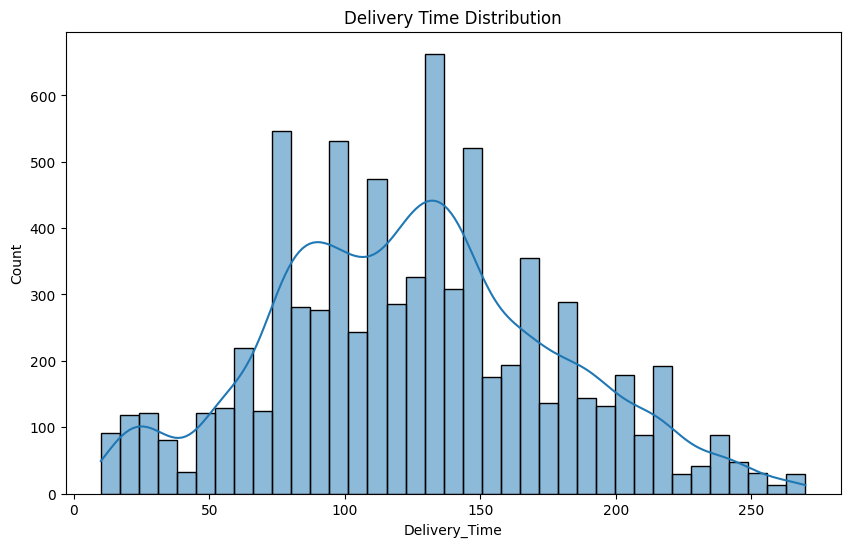

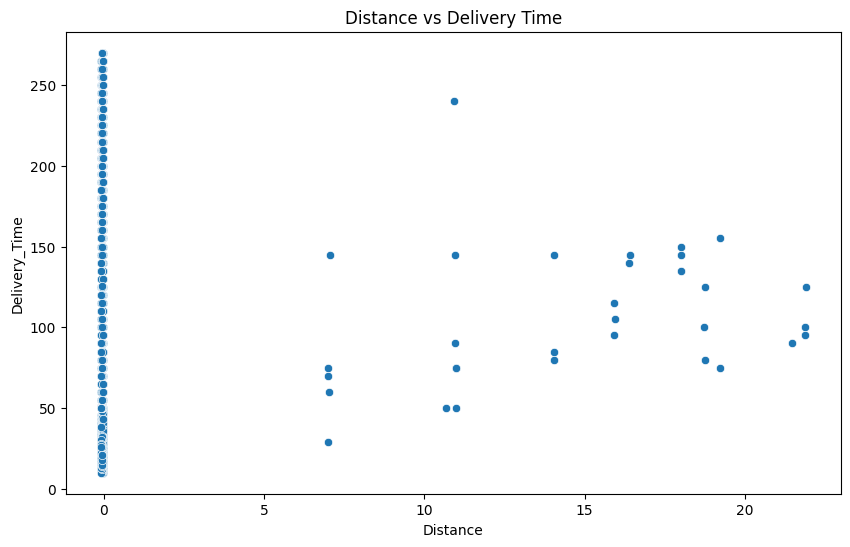

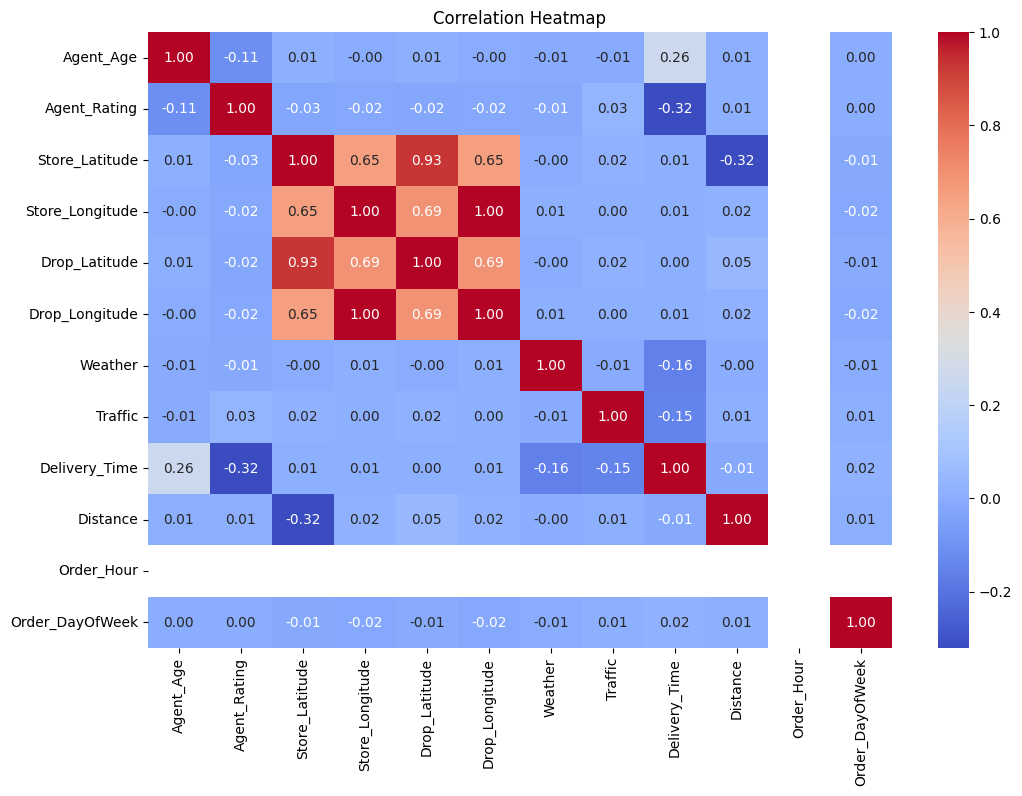

In [ ]:
# Distribution of Delivery Time
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time'], kde=True)
plt.title("Delivery Time Distribution")
plt.show()

# Scatter plot of Distance vs Delivery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Distance', y='Delivery_Time')
plt.title("Distance vs Delivery Time")
plt.show()

# Heatmap for correlation
# Select only numerical columns before calculating the correlation
numerical_df = df.select_dtypes(include=np.number)
corr = numerical_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# ***5. Model Development:***

In [ ]:
# Features and Target
X = df[['Agent_Age', 'Agent_Rating', 'Distance', 'Order_Hour', 'Order_DayOfWeek', 'Weather', 'Traffic']]
y = df['Delivery_Time']

# Split Data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_rf = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor RMSE: {rf_rmse}")
print(f"Random Forest Regressor MAE: {rf_mae}")
print(f"Random Forest Regressor R-squared: {rf_r2}")

# Model: Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_gb = gb_model.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting Regressor RMSE: {gb_rmse}")
print(f"Gradient Boosting Regressor MAE: {gb_mae}")
print(f"Gradient Boosting Regressor R-squared: {gb_r2}")


Random Forest Regressor RMSE: 38.66871501346213
Random Forest Regressor MAE: 27.553960129273253
Random Forest Regressor R-squared: 0.45284571494442727
Gradient Boosting Regressor RMSE: 36.6048704386215
Gradient Boosting Regressor MAE: 25.96947001628119
Gradient Boosting Regressor R-squared: 0.509693024441924


# ***6. Model Tracking with MLflow:***

In [ ]:
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.8/733.8 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 14.3 MB/s eta 0:00:00


In [ ]:
import mlflow
import mlflow.sklearn

# Log Random Forest Model
with mlflow.start_run():
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    mlflow.log_metric("RMSE", rf_rmse)
    mlflow.log_metric("MAE", rf_mae)
    mlflow.log_metric("R2", rf_r2)

# Log Gradient Boosting Model
with mlflow.start_run():
    mlflow.sklearn.log_model(gb_model, "gradient_boosting_model")
    mlflow.log_metric("RMSE", gb_rmse)
    mlflow.log_metric("MAE", gb_mae)
    mlflow.log_metric("R2", gb_r2)

2025/06/27 07:43:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/06/27 07:43:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/06/27 07:43:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/06/27 07:43:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# ***7. Streamlit Application for User Interface:***

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import joblib


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save the model
joblib.dump(rf_model, 'best_model.pkl')
print("Model saved as best_model.pkl")



Model saved as best_model.pkl


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Amazon Delivery Time Predictor", layout="centered")
st.title("📦 Amazon Delivery Time Prediction")

# Load trained model
model = joblib.load("best_model.pkl")

st.markdown("Enter the details below to estimate delivery time (in minutes):")

# Input fields
agent_age = st.slider("Agent Age", 18, 60, 30)
agent_rating = st.slider("Agent Rating", 1.0, 5.0, 4.5, 0.1)
distance = st.slider("Distance (in km)", 0.1, 50.0, 5.0)

weather = st.selectbox("Weather", ["Cloudy", "Fog", "Sandstorms", "Stormy", "Sunny", "Windy"])
traffic = st.selectbox("Traffic", ["High", "Jam", "Low", "Medium"])
vehicle = st.selectbox("Vehicle Type", ["electric_scooter", "motorcycle", "scooter"])
area = st.selectbox("Delivery Area", ["Metropolitian", "Urban"])
category = st.selectbox("Product Category", ["Clothing", "Cosmetics", "Electronics", "Furniture", "Medicines", "Sports", "Toys"])

# Manual One-Hot Encoding
def create_input():
    data = {
        "Agent_Age": agent_age,
        "Agent_Rating": agent_rating,
        "Distance": distance
    }

    for col in ["Weather_Cloudy", "Weather_Fog", "Weather_Sandstorms", "Weather_Stormy", "Weather_Sunny", "Weather_Windy",
                "Traffic_High", "Traffic_Jam", "Traffic_Low", "Traffic_Medium",
                "Vehicle_electric_scooter", "Vehicle_motorcycle", "Vehicle_scooter",
                "Area_Metropolitian", "Area_Urban",
                "Category_Clothing", "Category_Cosmetics", "Category_Electronics",
                "Category_Furniture", "Category_Medicines", "Category_Sports", "Category_Toys"]:
        data[col] = 0

    # Activate selected features
    data[f"Weather_{weather}"] = 1
    data[f"Traffic_{traffic}"] = 1
    data[f"Vehicle_{vehicle}"] = 1
    data[f"Area_{area}"] = 1
    data[f"Category_{category}"] = 1

    return pd.DataFrame([data])

# Predict button
if st.button("Predict Delivery Time"):
    input_df = create_input()
    prediction = model.predict(input_df)[0]
    st.success(f"📦 Estimated Delivery Time: {round(prediction, 2)} minutes")


2025-06-27 07:43:44.749 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-27 07:43:44.750 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-27 07:43:44.893 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-06-27 07:43:44.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-27 07:43:44.895 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-27 07:43:45.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-27 07:43:45.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="Amazon Delivery Time Predictor", layout="centered")
st.title("📦 Amazon Delivery Time Prediction")

model = joblib.load("best_model.pkl")

st.markdown("Enter the details below to estimate delivery time (in minutes):")

agent_age = st.slider("Agent Age", 18, 60, 30)
agent_rating = st.slider("Agent Rating", 1.0, 5.0, 4.5, 0.1)
distance = st.slider("Distance (in km)", 0.1, 50.0, 5.0)

weather = st.selectbox("Weather", ["Cloudy", "Fog", "Sandstorms", "Stormy", "Sunny", "Windy"])
traffic = st.selectbox("Traffic", ["High", "Jam", "Low", "Medium"])
vehicle = st.selectbox("Vehicle Type", ["electric_scooter", "motorcycle", "scooter"])
area = st.selectbox("Delivery Area", ["Metropolitian", "Urban"])
category = st.selectbox("Product Category", ["Clothing", "Cosmetics", "Electronics", "Furniture", "Medicines", "Sports", "Toys"])

def create_input():
    data = {
        "Agent_Age": agent_age,
        "Agent_Rating": agent_rating,
        "Distance": distance
    }

    for col in ["Weather_Cloudy", "Weather_Fog", "Weather_Sandstorms", "Weather_Stormy", "Weather_Sunny", "Weather_Windy",
                "Traffic_High", "Traffic_Jam", "Traffic_Low", "Traffic_Medium",
                "Vehicle_electric_scooter", "Vehicle_motorcycle", "Vehicle_scooter",
                "Area_Metropolitian", "Area_Urban",
                "Category_Clothing", "Category_Cosmetics", "Category_Electronics",
                "Category_Furniture", "Category_Medicines", "Category_Sports", "Category_Toys"]:
        data[col] = 0

    data[f"Weather_{weather}"] = 1
    data[f"Traffic_{traffic}"] = 1
    data[f"Vehicle_{vehicle}"] = 1
    data[f"Area_{area}"] = 1
    data[f"Category_{category}"] = 1

    return pd.DataFrame([data])

if st.button("Predict Delivery Time"):
    input_df = create_input()
    prediction = model.predict(input_df)[0]
    st.success(f"📦 Estimated Delivery Time: {round(prediction, 2)} minutes")
'''

# Save to app.py
with open("app.py", "w") as f:
    f.write(streamlit_code)

print("✅ app.py file created in the current working directory.")


✅ app.py file created in the current working directory.


In [ ]:
from google.colab import files
files.download("app.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("app.py")
files.download("best_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!streamlit run app.py





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.139.44.139:8501

